<a href="https://colab.research.google.com/github/HarshiniArulmani2006/Harshini-codeboosters-2026/blob/main/Day_2/Day_2_data_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All Libraries imported successfully!!")
print(f"Pandas Version: {pd.__version__}")
print(f"SQLite3 Version: {sqlite3.version}")

All Libraries imported successfully!!
Pandas Version: 2.2.2
SQLite3 Version: 2.6.0


In [ ]:
df=pd.read_csv('/content/student_performance.csv')
print(f"Dataset loaded:{df.shape[0]} students,{df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 3 row:")
df.head(3)

Dataset loaded:30 students,13 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 row:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
#creating database in collab , collab has no db
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(f"Database college.db created successfully")
print(f"Number of Rows: {count}")

Database college.db created successfully
Number of Rows: 30


In [ ]:
def run_query(sql, description="student"):
    if description:
        print(description)
    result = pd.read_sql_query(sql, conn)
    print(result.to_string(index=False))
    return result
print("Helper function 'run_query' defined successfully!")
print("Usage: run_query(sql_string, description_label)")

Helper function 'run_query' defined successfully!
Usage: run_query(sql_string, description_label)


In [ ]:
query1="""
SELECT student_id,name,department,math_score,attendance_percentage
FROM students
LIMIT 10
"""
result1=run_query(query1,"Query 1:First 10 students (SELECT + LIMIT)")

Query 1:First 10 students (SELECT + LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [ ]:
query2="""
SELECT student_id,name
FROM students
LIMIT 5
"""
result2=run_query(query2,"Query 2:Students Id and Name (SELECT + LIMIT)")

Query 2:Students Id and Name (SELECT + LIMIT)
 student_id         name
       1001 Aarav Sharma
       1002  Priya Patel
       1003  Rohit Verma
       1004  Sneha Reddy
       1005   Arjun Nair


In [ ]:
query3="""
SELECT name,department,math_score
FROM students
WHERE math_score>=90
ORDER BY math_score DESC
LIMIT 7
"""
result3=run_query(query3,"Query 3 Top Score (SELECT + LIMIT)")

Query 3 Top Score (SELECT + LIMIT)
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [ ]:
query4="""
SELECT name,department,math_score,science_score,programming_score,attendance_percentage
FROM students
WHERE department='Computer Science'
ORDER BY programming_score DESC
"""
result4=run_query(query4,"Query 4 Computer Students Mark (SELECT + LIMIT)")
print(f"\nTotal number of CS students: {len(result4)}")

Query 4 Computer Students Mark (SELECT + LIMIT)
          name       department  math_score  science_score  programming_score  attendance_percentage
    Ananya Das Computer Science          95             89                 97                     98
   Tanvi Mehta Computer Science          93             90                 96                     97
    Arjun Nair Computer Science          92             88                 95                     90
Akanksha Yadav Computer Science          91             93                 94                     95
   Divya Singh Computer Science          88             91                 93                     96
Swati Kulkarni Computer Science          90             87                 92                     94
  Aarav Sharma Computer Science          85             78                 91                     92
     Amit Bose Computer Science          86             82                 89                     91
    Suresh Rao Computer Science          83

In [ ]:
query5="""
SELECT name,department,attendance_percentage
FROM students
WHERE department!='Civil'AND attendance_percentage>90
ORDER BY attendance_percentage DESC
"""
result5=run_query(query5,"Query 5 High Attendance Percentage")

Query 5 High Attendance Percentage
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [27]:
query6="""
SELECT name,department,attendance_percentage
FROM students
WHERE department!='Mechanical'AND attendance_percentage>93
ORDER BY attendance_percentage DESC
LIMIT 5
"""
result6=run_query(query6,"Query 6 High Attendance Percentage (SELECT + LIMIT)")

Query 6 High Attendance Percentage (SELECT + LIMIT)
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94


In [30]:
query7="""
SELECT department,
COUNT(*) AS num_students,
ROUND(AVG(math_score),2) AS avg_math_score,
ROUND(AVG(science_score),2) AS avg_science_score,
ROUND(AVG(programming_score),2) AS avg_programming_score,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY department
ORDER BY avg_math_score DESC
"""
result7=run_query(query7,"Query 7 Average")

Query 7 Average
      department  num_students  avg_math_score  avg_science_score  avg_programming_score  avg_attendance
Computer Science            13           85.62              84.46                  89.23           90.69
      Mechanical             6           71.00              76.50                  49.33           83.50
     Electronics             6           71.00              74.17                  61.50           80.33
           Civil             5           63.40              66.60                  40.60           74.60


In [32]:
query8="""
SELECT department,
ROUND(AVG(math_score),2)AS avg_math_score,
COUNT(*)AS num_students
FROM students
GROUP BY department
HAVING AVG(math_score)>70
ORDER BY avg_math_score DESC
"""
result8=run_query(query8,"Query 8 Having")

Query 8 Having
      department  avg_math_score  num_students
Computer Science           85.62            13
      Mechanical           71.00             6
     Electronics           71.00             6


In [35]:
query9="""
SELECT gender,
COUNT(*) AS num_students,
ROUND(AVG(math_score),2) AS avg_math_score,
ROUND(AVG(programming_score),2) AS avg_programming_score,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender
"""
result9=run_query(query9,"Query 9 Gender")


Query 9 Gender
gender  num_students  avg_math_score  avg_programming_score  avg_attendance
Female            15           78.47                   70.2           88.53
  Male            15           73.67                   65.0           80.47


In [51]:
query10 = """
SELECT gender,
ROUND(AVG(programming_score),2) AS avg_programming_score
FROM students
GROUP BY gender
HAVING gender='Female'
"""
result10=run_query(query10,"Query 10 Gender")

Query 10 Gender
gender  avg_programming_score
Female                   70.2


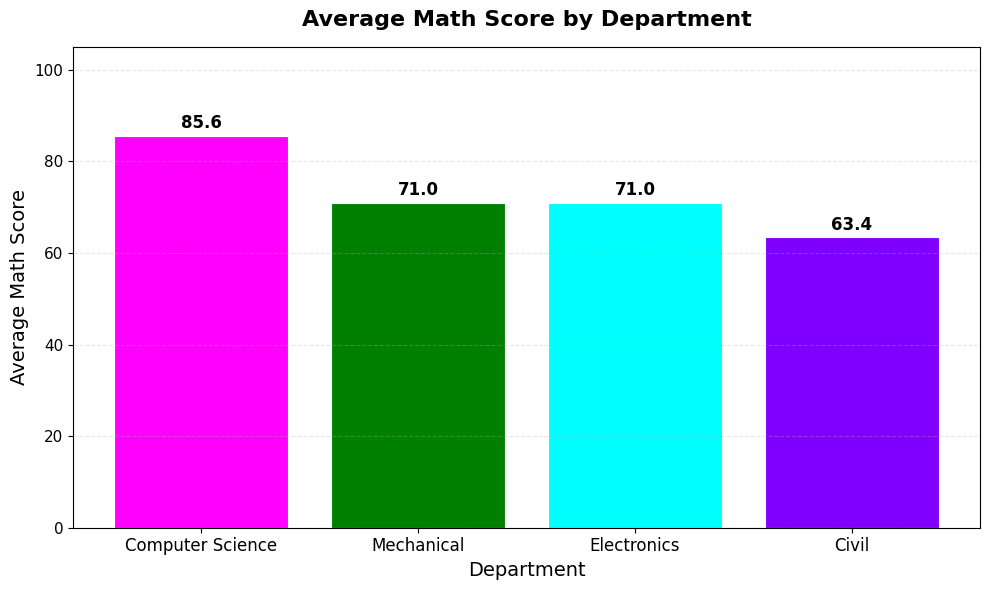

In [47]:
#get data using sql
chart1_sql="""
SELECT department,
ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_colors=['#FF00FF','#008000','#00FFFF','#7F00FF']
bars=ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)
for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f"{height:.1f}",
      ha='center',va='bottom',
      fontsize=12,fontweight='bold',
      color='black'
  )


ax.set_title("Average Math Score by Department",fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel("Department",fontsize=14)
ax.set_ylabel("Average Math Score",fontsize=14)
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=12)
ax.tick_params(axis='y',labelsize=11)
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.show()
